# ============================================================
# MODELO HÍBRIDO — ELÉCTRICO + VIBRACIÓN
# ============================================================


In [ ]:

# ============================================================
# 0. INSTALACIÓN
# ============================================================

!pip install h2o optuna optuna-dashboard plotly seaborn

In [9]:
# ============================================================
# 1. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import h2o
from h2o.estimators import H2OExtendedIsolationForestEstimator
import optuna
from optuna.trial import TrialState
import optuna.visualization as vis
import os
import json
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "browser"

In [ ]:
# ============================================================
# 2. CONFIGURACIÓN
# ============================================================


RUTA_FEATURES   = "features"
CSV_INDEX       = "Motor_DB/index/master_index.csv"
RUTA_RESULTADOS = "resultados_hibrido_2"
os.makedirs(RUTA_RESULTADOS, exist_ok=True)

N_TRIALS = 500
SEED     = 42

N_FEATURES  = 39   # 24 + 15
study_name_elec = "EIF_electrico_v2_39features"
study_name_vib  = "EIF_vibracion_v2_39features"


In [ ]:
# ============================================================
# SEPARAR COLUMNAS
# ============================================================
cols_todas      = pd.read_csv("features/train/sano_train.csv", nrows=0).columns.tolist()
cols_electricas = [c for c in cols_todas if c.startswith(("u_", "v_", "w_"))]
cols_vibracion  = [c for c in cols_todas if not c.startswith(("u_", "v_", "w_"))]

print(f"Eléctricas : {len(cols_electricas)} columnas → {cols_electricas}")
print(f"Vibración  : {len(cols_vibracion)} columnas → {cols_vibracion}")

EXT_MAX_ELEC = len(cols_electricas) - 1  # 23  (8 features × 3 señales = 24 → max 23)
EXT_MAX_VIB  = len(cols_vibracion)  - 1  # 14  (3 features × 5 señales = 15 → max 14)

Eléctricas : 18 columnas → ['u_katz', 'u_perm_entropy', 'u_kurtosis', 'u_rms', 'u_pico', 'u_cresta', 'v_katz', 'v_perm_entropy', 'v_kurtosis', 'v_rms', 'v_pico', 'v_cresta', 'w_katz', 'w_perm_entropy', 'w_kurtosis', 'w_rms', 'w_pico', 'w_cresta']
Vibración  : 30 columnas → ['front_DE_Y_katz', 'front_DE_Y_perm_entropy', 'front_DE_Y_kurtosis', 'front_DE_Y_rms', 'front_DE_Y_pico', 'front_DE_Y_cresta', 'front_DE_Z_katz', 'front_DE_Z_perm_entropy', 'front_DE_Z_kurtosis', 'front_DE_Z_rms', 'front_DE_Z_pico', 'front_DE_Z_cresta', 'rear_NDE_Y_katz', 'rear_NDE_Y_perm_entropy', 'rear_NDE_Y_kurtosis', 'rear_NDE_Y_rms', 'rear_NDE_Y_pico', 'rear_NDE_Y_cresta', 'rear_NDE_Z_katz', 'rear_NDE_Z_perm_entropy', 'rear_NDE_Z_kurtosis', 'rear_NDE_Z_rms', 'rear_NDE_Z_pico', 'rear_NDE_Z_cresta', 'housing_katz', 'housing_perm_entropy', 'housing_kurtosis', 'housing_rms', 'housing_pico', 'housing_cresta']


In [4]:
# ============================================================
# 3. INICIALIZAR H2O
# ============================================================

h2o.init(
    nthreads=-1,       # usa todos los cores disponibles
    max_mem_size="10G"  # ajusta según tu RAM
)


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "21.0.10" 2026-01-20; OpenJDK Runtime Environment (build 21.0.10+7-Ubuntu-124.04); OpenJDK 64-Bit Server VM (build 21.0.10+7-Ubuntu-124.04, mixed mode, sharing)
  Starting server from /home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpip04q08h
  JVM stdout: /tmp/tmpip04q08h/h2o_ariel_started_from_python.out
  JVM stderr: /tmp/tmpip04q08h/h2o_ariel_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Europe/Madrid
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_ariel_jmukqg
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,9.98 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [5]:
# ============================================================
# 4. CARGAR DATOS
# ============================================================

print("Cargando datos...\n")

index        = pd.read_csv(CSV_INDEX)
carpeta_test = os.path.join(RUTA_FEATURES, "test")

# Cargar frames completos
train_full    = h2o.import_file(os.path.join(RUTA_FEATURES, "train", "sano_train.csv"))
val_full      = h2o.import_file(os.path.join(RUTA_FEATURES, "val",   "sano.csv"))
test_sano_full = h2o.import_file(os.path.join(RUTA_FEATURES, "test",  "sano.csv"))

fallos_full = {}
for archivo in sorted(os.listdir(carpeta_test)):
    if archivo.endswith(".csv") and archivo != "sano.csv":
        nombre = archivo.replace(".csv", "")
        fallos_full[nombre] = h2o.import_file(os.path.join(carpeta_test, archivo))

# Seleccionar columnas por modelo
train_elec     = train_full[cols_electricas]
train_vib      = train_full[cols_vibracion]

val_elec       = val_full[cols_electricas]
val_vib        = val_full[cols_vibracion]

test_sano_elec = test_sano_full[cols_electricas]
test_sano_vib  = test_sano_full[cols_vibracion]

fallos_elec = {n: f[cols_electricas] for n, f in fallos_full.items()}
fallos_vib  = {n: f[cols_vibracion]  for n, f in fallos_full.items()}

print(f"\nTrain eléctrico : {train_elec.shape}")
print(f"Train vibración : {train_vib.shape}")

Cargando datos...

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |██████████████

In [6]:
# ============================================================
# 5. FUNCIONES AUXILIARES
# ============================================================

def agregar_por_experimento_variable(scores_array, n_archivos):
    n = len(scores_array)
    ventanas_por_exp = n // n_archivos
    medianas = []
    for i in range(0, n, ventanas_por_exp):
        grupo = scores_array[i:i + ventanas_por_exp]
        if len(grupo) > 0:
            medianas.append(np.median(grupo))
    return np.array(medianas)

def calcular_umbral(model, train_frame, val_frame, ventanas=100):
    s_train = model.predict(train_frame)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_frame)["anomaly_score"].as_data_frame().values.flatten()
    med_train = agregar_por_experimento_variable(s_train, len(s_train)//ventanas)
    med_val   = agregar_por_experimento_variable(s_val,   len(s_val)//ventanas)
    todos = np.concatenate([med_train, med_val])
    return np.mean(todos) + 3 * np.std(todos), np.mean(todos), np.std(todos)

In [ ]:
# ============================================================
# OPTUNA — MODELO ELÉCTRICO
# ============================================================

print("\n" + "="*60)
print("OPTIMIZANDO MODELO ELÉCTRICO")
print("="*60)

def objective_elec(trial):
    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX_ELEC)

    model = H2OExtendedIsolationForestEstimator(
        ntrees=ntrees, sample_size=sample_size,
        extension_level=extension_level, seed=SEED
    )
    try:
        model.train(training_frame=train_elec)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    s_train = model.predict(train_elec)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_elec)["anomaly_score"].as_data_frame().values.flatten()
    med_t   = agregar_por_experimento_variable(s_train, 30)
    med_v   = agregar_por_experimento_variable(s_val,    6)
    todos   = np.concatenate([med_t, med_v])
    umbral  = np.mean(todos) + 3 * np.std(todos)

    trial.set_user_attr("umbral", round(float(umbral), 6))
    return umbral

study_elec = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_elec.db",
    study_name=study_name_elec, load_if_exists=True
)
study_elec.optimize(objective_elec, n_trials=N_TRIALS, show_progress_bar=True)

In [ ]:
# ============================================================
# OPTUNA — MODELO VIBRACIÓN
# ============================================================
print("\n" + "="*60)
print("OPTIMIZANDO MODELO VIBRACIÓN")
print("="*60)

def objective_vib(trial):
    ntrees          = trial.suggest_int("ntrees",          100, 800)
    sample_size     = trial.suggest_int("sample_size",     256, 1060, step=64)
    extension_level = trial.suggest_int("extension_level", 0,   EXT_MAX_VIB)

    model = H2OExtendedIsolationForestEstimator(
        ntrees=ntrees, sample_size=sample_size,
        extension_level=extension_level, seed=SEED
    )
    try:
        model.train(training_frame=train_vib)
    except Exception:
        raise optuna.exceptions.TrialPruned()

    s_train = model.predict(train_vib)["anomaly_score"].as_data_frame().values.flatten()
    s_val   = model.predict(val_vib)["anomaly_score"].as_data_frame().values.flatten()
    med_t   = agregar_por_experimento_variable(s_train, 30)
    med_v   = agregar_por_experimento_variable(s_val,    6)
    todos   = np.concatenate([med_t, med_v])
    umbral  = np.mean(todos) + 3 * np.std(todos)

    trial.set_user_attr("umbral", round(float(umbral), 6))
    return umbral

study_vib = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_vib.db",
    study_name=study_name_vib, load_if_exists=True
)
study_vib.optimize(objective_vib, n_trials=N_TRIALS, show_progress_bar=True)

In [8]:
# ============================================================
# MODELOS FINALES
# ============================================================

study_elec = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_elec.db",
    study_name="EIF_electrico", load_if_exists=True
)
study_vib = optuna.create_study(
    direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED),
    storage="sqlite:///resultados_hibrido/optuna_vib.db",
    study_name="EIF_vibracion", load_if_exists=True
)
print("\n" + "="*60)
print("ENTRENANDO MODELOS FINALES")
print("="*60)

best_elec = study_elec.best_trial
best_vib  = study_vib.best_trial

print(f"\nMejor umbral eléctrico : {best_elec.value:.6f}")
print(f"  ntrees={best_elec.params['ntrees']}, "
      f"sample_size={best_elec.params['sample_size']}, "
      f"extension_level={best_elec.params['extension_level']}")

print(f"\nMejor umbral vibración : {best_vib.value:.6f}")
print(f"  ntrees={best_vib.params['ntrees']}, "
      f"sample_size={best_vib.params['sample_size']}, "
      f"extension_level={best_vib.params['extension_level']}")

# Modelo eléctrico
modelo_elec = H2OExtendedIsolationForestEstimator(
    ntrees=best_elec.params["ntrees"],
    sample_size=best_elec.params["sample_size"],
    extension_level=best_elec.params["extension_level"],
    seed=SEED
)
modelo_elec.train(training_frame=train_elec)

# Modelo vibración
modelo_vib = H2OExtendedIsolationForestEstimator(
    ntrees=best_vib.params["ntrees"],
    sample_size=best_vib.params["sample_size"],
    extension_level=best_vib.params["extension_level"],
    seed=SEED
)
modelo_vib.train(training_frame=train_vib)

# Umbrales finales
umbral_elec, media_e, std_e = calcular_umbral(modelo_elec, train_elec, val_elec)
umbral_vib,  media_v, std_v = calcular_umbral(modelo_vib,  train_vib,  val_vib)

print(f"\nUmbral eléctrico: {umbral_elec:.6f} (media={media_e:.4f}, std={std_e:.4f})")
print(f"Umbral vibración: {umbral_vib:.6f}  (media={media_v:.4f}, std={std_v:.4f})")

# Guardar hiperparámetros
with open(os.path.join(RUTA_RESULTADOS, "hiperparametros.json"), "w") as f:
    json.dump({
        "electrico": best_elec.params,
        "vibracion": best_vib.params,
        "umbral_elec": umbral_elec,
        "umbral_vib":  umbral_vib
    }, f, indent=2)

[I 2026-05-11 17:15:55,143] Using an existing study with name 'EIF_electrico' instead of creating a new one.
[I 2026-05-11 17:15:55,173] Using an existing study with name 'EIF_vibracion' instead of creating a new one.



ENTRENANDO MODELOS FINALES

Mejor umbral eléctrico : 0.391126
  ntrees=109, sample_size=1024, extension_level=17

Mejor umbral vibración : 0.394251
  ntrees=563, sample_size=1024, extension_level=28
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest Model Build progress: |██████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%

Umbral eléctrico: 0.391126 (media=0.3557, std=0.0118)
Umbral vibración: 0.394251  (media=0.3525, std=0.0139)


In [10]:
# ============================================================
# 10. EVALUACIÓN POR EXPERIMENTO
# ============================================================

print("\n" + "="*60)
print("EVALUACIÓN POR EXPERIMENTO")
print("="*60)

def evaluar(model_e, model_v, umbral_e, umbral_v, frame_e, frame_v, n_archivos, nombre):
    s_e = model_e.predict(frame_e)["anomaly_score"].as_data_frame().values.flatten()
    s_v = model_v.predict(frame_v)["anomaly_score"].as_data_frame().values.flatten()

    med_e = agregar_por_experimento_variable(s_e, n_archivos)
    med_v = agregar_por_experimento_variable(s_v, n_archivos)

    det_e    = med_e > umbral_e
    det_v    = med_v > umbral_v
    det_comb = det_e | det_v  # OR lógico

    return {
        "grupo":          nombre,
        "n_exp":          len(med_e),
        "det_elec_%":     round(np.mean(det_e)    * 100, 1),
        "det_vib_%":      round(np.mean(det_v)    * 100, 1),
        "det_combinado_%": round(np.mean(det_comb) * 100, 1),
        "med_e": med_e,
        "med_v": med_v,
    }

resultados    = []
datos_box_e   = []
datos_box_v   = []
datos_box_c   = []

# Sano test
n_sano = len(index[(index["Split"] == "test") & (index["Maquina"] == "h")])
res = evaluar(modelo_elec, modelo_vib, umbral_elec, umbral_vib,
              test_sano_elec, test_sano_vib, n_sano, "sano_test")
resultados.append(res)

for m in res["med_e"]: datos_box_e.append({"grupo": "sano_test", "mediana": m})
for m in res["med_v"]: datos_box_v.append({"grupo": "sano_test", "mediana": m})
for m in (res["med_e"] + res["med_v"]) / 2:
    datos_box_c.append({"grupo": "sano_test", "mediana": m})

print(f"\n  sano_test → elec: {res['det_elec_%']}% | "
      f"vib: {res['det_vib_%']}% | combinado: {res['det_combinado_%']}%  ← idealmente 0%")

# Fallos
print()
for nombre in sorted(fallos_elec.keys()):
    n_arch = len(index[(index["Split"] == "test") & (index["Fallo"] == nombre)])
    res = evaluar(modelo_elec, modelo_vib, umbral_elec, umbral_vib,
                  fallos_elec[nombre], fallos_vib[nombre], n_arch, nombre)
    resultados.append(res)

    for m in res["med_e"]: datos_box_e.append({"grupo": nombre, "mediana": m})
    for m in res["med_v"]: datos_box_v.append({"grupo": nombre, "mediana": m})
    for m in (res["med_e"] + res["med_v"]) / 2:
        datos_box_c.append({"grupo": nombre, "mediana": m})

    print(f"  {nombre:<50} "
          f"elec: {res['det_elec_%']:>5.1f}% | "
          f"vib: {res['det_vib_%']:>5.1f}% | "
          f"combinado: {res['det_combinado_%']:>5.1f}%")

# Guardar CSV
df_res = pd.DataFrame([{k: v for k, v in r.items()
                         if k not in ["med_e", "med_v"]}
                        for r in resultados])
df_res.to_csv(os.path.join(RUTA_RESULTADOS, "resultados_hibrido.csv"), index=False)



EVALUACIÓN POR EXPERIMENTO
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%

  sano_test → elec: 12.5% | vib: 37.5% | combinado: 50.0%  ← idealmente 0%

extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_barra_rota_1_DTC_S1200                       elec:  50.0% | vib:  75.0% | combinado: 100.0%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

...

███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S1500               elec:   0.0% | vib:   0.0% | combinado:   0.0%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_S900                elec:   0.0% | vib:  33.3% | combinado:  33.3%
extendedisolationforest prediction progress: |███████████████████████████████████| (done) 100%
extendedisolationforest prediction progress: |

/home/ariel/Documents/UPV/TFM/EIF/ambiente/lib/python3.12/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


███████████████████████████████████| (done) 100%
  fallo_rodamiento_groove_scalar_STrap               elec:   0.0% | vib:   0.0% | combinado:   0.0%


/tmp/ipykernel_34951/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


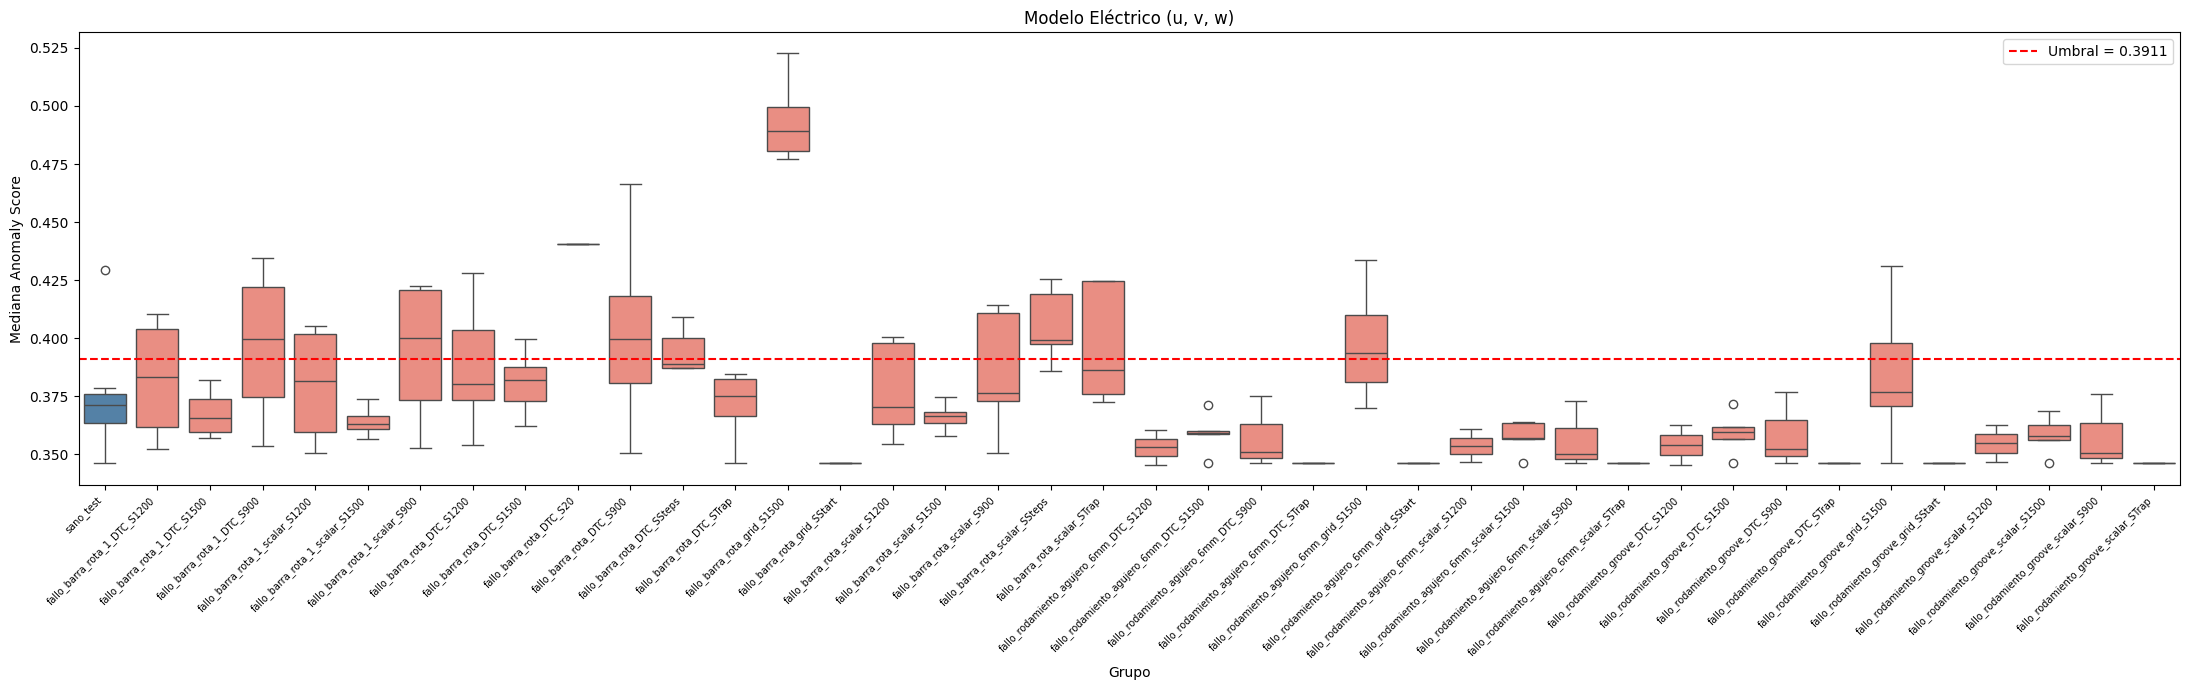

/tmp/ipykernel_34951/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


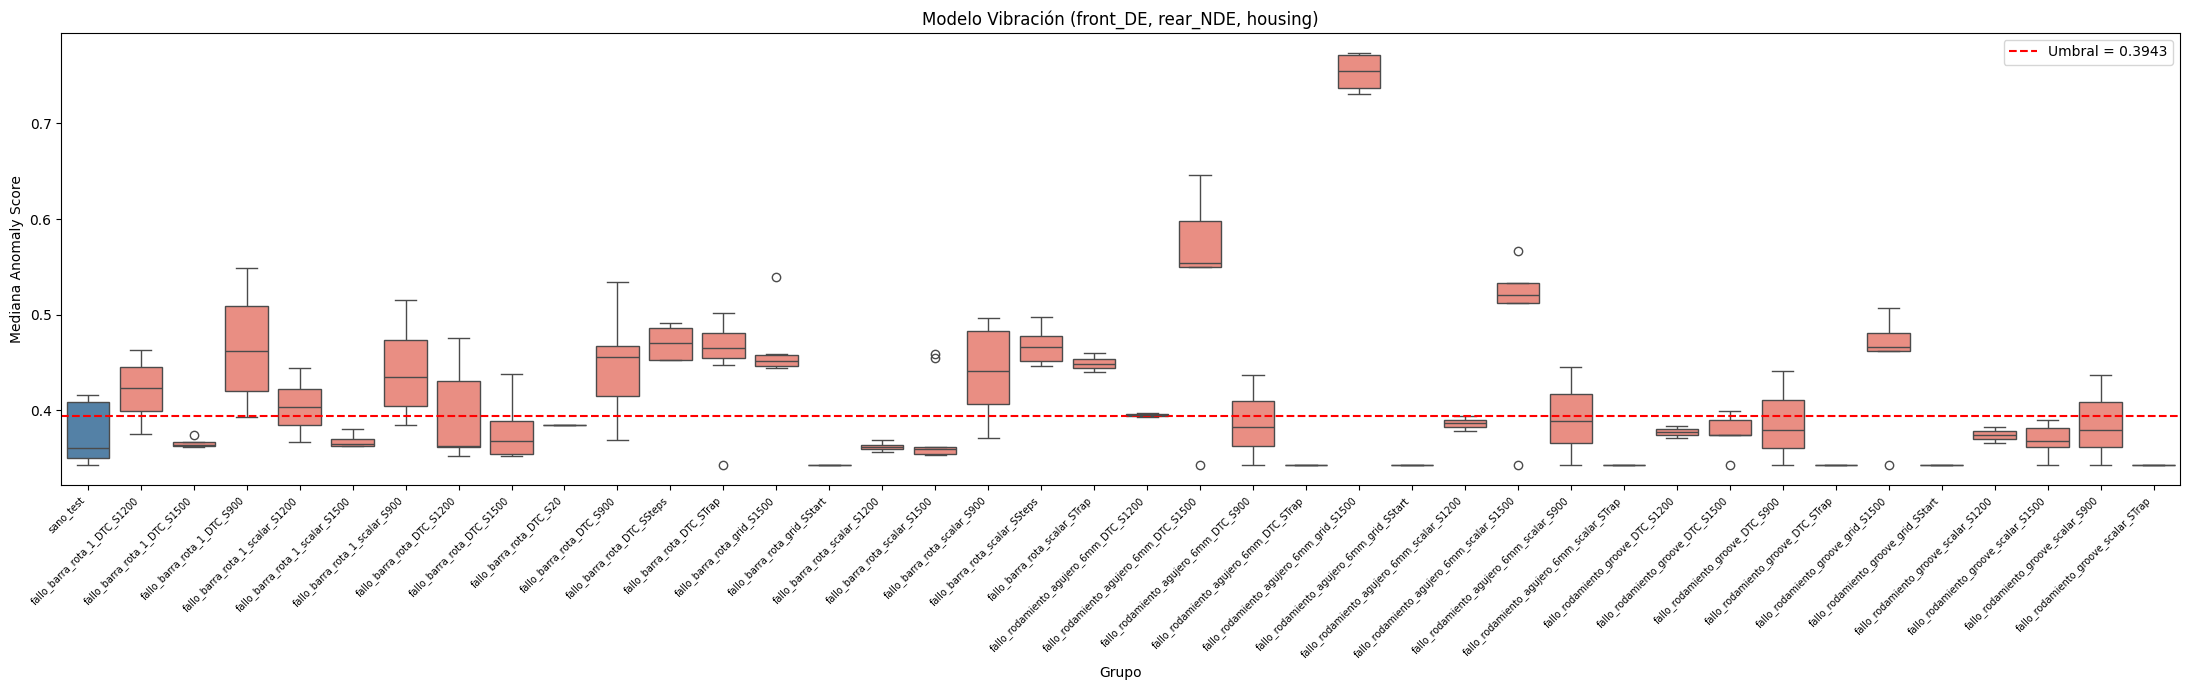

/tmp/ipykernel_34951/3186253264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],


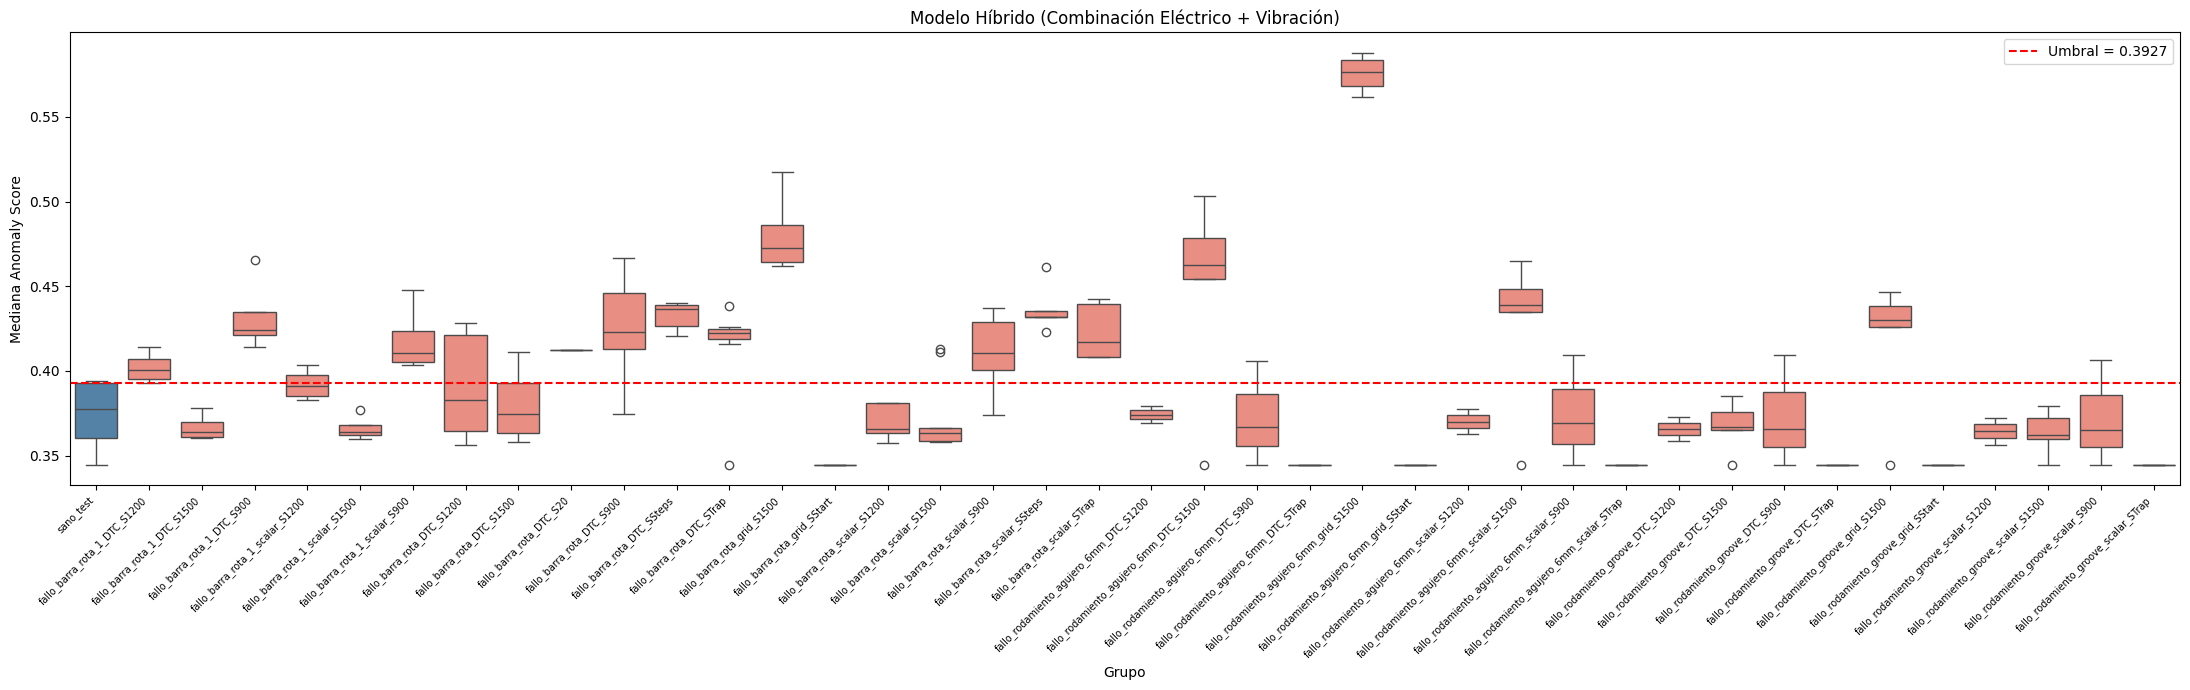


✅ Todo completado.
Umbral eléctrico : 0.391126
Umbral vibración : 0.394251


In [11]:

# ============================================================
# 11. BOXPLOT ESTILO PAPER
# ============================================================

orden = ["sano_test"] + sorted([n for n in fallos_elec.keys()])
colores = {g: "steelblue" if "sano" in g else "salmon" for g in orden}

def hacer_boxplot(datos, umbral, titulo, filename):
    df_box = pd.DataFrame(datos)
    plt.figure(figsize=(22, 7))
    sns.boxplot(data=df_box[df_box["grupo"].isin(orden)],
                x="grupo", y="mediana", order=orden, palette=colores)
    plt.axhline(y=umbral, color="red", linestyle="--", linewidth=1.5,
                label=f"Umbral = {umbral:.4f}")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.title(titulo)
    plt.xlabel("Grupo")
    plt.ylabel("Mediana Anomaly Score")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RUTA_RESULTADOS, filename), dpi=150)
    plt.show()

# Gráfica 1 — Solo eléctrico
hacer_boxplot(datos_box_e, umbral_elec,
              "Modelo Eléctrico (u, v, w)",
              "boxplot_electrico.png")

# Gráfica 2 — Solo vibración
hacer_boxplot(datos_box_v, umbral_vib,
              "Modelo Vibración (front_DE, rear_NDE, housing)",
              "boxplot_vibracion.png")

# Gráfica 3 — Combinado (promedio scores)
umbral_comb = (umbral_elec + umbral_vib) / 2
hacer_boxplot(datos_box_c, umbral_comb,
              "Modelo Híbrido (Combinación Eléctrico + Vibración)",
              "boxplot_hibrido.png")

print("\n✅ Todo completado.")
print(f"Umbral eléctrico : {umbral_elec:.6f}")
print(f"Umbral vibración : {umbral_vib:.6f}")